# Visión por computadora I
## Trabajo práctico 3

**Integrantes:**
* Diego Vazquez
* Hernando Scheidl
* Martín Lacheski
* Nicolás Lastra

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template`. Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección.

### Preparación

Cargamos las imágenes y el template, y definimos las funciones para visualizar los resultados.

In [1]:
import glob
import os

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

RAIZ = '../../Material_TPs/TP3/'


def cargar(path, grises=False):
    """Lee la imagen aplanando el canal alfa sobre fondo blanco."""
    im = cv.imread(path, cv.IMREAD_UNCHANGED)
    if im.shape[2] == 4:
        a = im[:, :, 3:4] / 255.0
        im = (im[:, :, :3] * a + 255 * (1 - a)).astype(np.uint8)
    return cv.cvtColor(im, cv.COLOR_BGR2GRAY) if grises else im


def bordes(gray):
    """Bordes de Canny con los umbrales derivados de Otsu."""
    blur = cv.GaussianBlur(gray, (5, 5), 0)
    t, _ = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return cv.Canny(blur, 0.5 * t, t)


# Template recortado al logo (sin margen blanco); el umbral de recorte sale de Otsu
template = cargar(RAIZ + 'template/pattern.png', grises=True)
t_otsu, _ = cv.threshold(template, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
ys, xs = np.where(template < t_otsu)
template = template[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
w, h = template.shape[::-1]
paths = sorted(glob.glob(RAIZ + 'images/*'))

# Bordes del template dilatados 1 px para tolerar pequeños desalineamientos
KERNEL = np.ones((3, 3), np.uint8)
t_bordes = cv.dilate(bordes(template), KERNEL).astype(np.float32)


def confianza(gray, M):
    """Correlación normalizada entre los bordes del template y los de la región detectada,
    llevada al plano del template con la homografía inversa."""
    region = cv.warpPerspective(gray, np.linalg.inv(M), (w, h), borderMode=cv.BORDER_REPLICATE)
    b = cv.dilate(bordes(region), KERNEL).astype(np.float32)
    return float(cv.matchTemplate(b, t_bordes, cv.TM_CCOEFF_NORMED)[0, 0])


def recortar(det, shape):
    """Limita la bounding box a los bordes de la imagen."""
    alto, ancho = shape[:2]
    x0, y0, x1, y1, *resto = det
    return (max(0.0, x0), max(0.0, y0), min(float(ancho), x1), min(float(alto), y1), *resto)


def suprimir_duplicados(dets):
    """Supresión de no-máximos: descarta una detección si su centro cae dentro de una caja ya
    aceptada de mayor confianza, o al revés. No necesita un umbral de IoU."""
    def contiene(a, b):
        cx, cy = (b[0] + b[2]) / 2, (b[1] + b[3]) / 2
        return a[0] <= cx <= a[2] and a[1] <= cy <= a[3]

    final = []
    for d in sorted(dets, key=lambda d: -d[4]):
        if not any(contiene(k, d) or contiene(d, k) for k in final):
            final.append(d)
    return final


def dibujar(img, dets):
    """Dibuja las bounding boxes (x0, y0, x1, y1, confianza, ...) con su confianza."""
    out = img.copy()
    for x0, y0, x1, y1, conf, *_ in dets:
        cv.rectangle(out, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 2)
        cv.putText(out, f'{conf:.2f}', (int(x0), max(12, int(y0) - 4)), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return out


def mostrar(paths, detector, cols=3):
    filas = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=(6 * cols, 5 * filas))
    for i, p in enumerate(paths):
        img = cargar(p)
        dets = detector(img)
        plt.subplot(filas, cols, i + 1)
        plt.imshow(cv.cvtColor(dibujar(img, dets), cv.COLOR_BGR2RGB))
        plt.title(f'{os.path.basename(p)}: {len(dets)} detección(es)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### 1. Obtener una detección del logo en cada imagen sin falsos positivos

Usamos SIFT + matching + homografía:
- Usamos el template y su negativo, porque el logo aparece rojo sobre blanco y también blanco sobre rojo.
- Hacemos el matching con FLANN y nos quedamos con los matches que pasan el test de Lowe.
- Con esos matches calculamos la homografía con RANSAC, que lleva las esquinas del template a la imagen. La tolerancia de RANSAC es relativa al tamaño del logo en la imagen, así el mismo criterio sirve para cualquier resolución.
- Dibujamos la bounding box que envuelve al polígono, recortada a los bordes de la imagen.
- Nos quedamos con la detección con más inliers entre el template y su negativo.

**Confianza:** llevamos la región detectada al plano del template con la homografía inversa y calculamos la correlación normalizada (`TM_CCOEFF_NORMED`) entre sus bordes de Canny y los del template. Usamos bordes, como se vio en clase, para que no influyan el color ni las zonas uniformes, y además el valor es el mismo para el logo normal y el invertido. No es una probabilidad: es una medida de cuánto coincide el contorno del logo detectado con el del template.

In [2]:
sift = cv.SIFT_create()
flann = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
pts = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
plantillas = [sift.detectAndCompute(t, None) for t in (template, 255 - template)]

RATIO = 0.7         # test de Lowe (valor propuesto en el paper de SIFT)
MIN_INLIERS = 8     # el doble de las 4 correspondencias mínimas que necesita una homografía
TOL_RANSAC = 0.03   # error de reproyección admitido, como fracción del ancho del logo en la imagen


def homografia(src_pts, dst_pts, ancho_logo):
    return cv.findHomography(src_pts, dst_pts, cv.RANSAC, TOL_RANSAC * ancho_logo)


def detectar_uno(img):
    """Devuelve [(x0, y0, x1, y1, confianza, inliers)] con la mejor detección, o []."""
    cv.setRNGSeed(0)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray, None)
    mejor = []
    for kp1, des1 in plantillas:
        matches = [m for m in flann.knnMatch(des1, des2, k=2) if len(m) == 2]
        good = [a for a, b in matches if a.distance < RATIO * b.distance]
        if len(good) < MIN_INLIERS:
            continue
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        escala = np.median([kp2[m.trainIdx].size / kp1[m.queryIdx].size for m in good])
        M, mask = homografia(src_pts, dst_pts, escala * w)
        if M is not None and mask.sum() >= MIN_INLIERS and (not mejor or mask.sum() > mejor[0][5]):
            q = cv.perspectiveTransform(pts, M).reshape(-1, 2)
            mejor = [recortar((*q.min(axis=0), *q.max(axis=0), confianza(gray, M), int(mask.sum())), img.shape)]
    return mejor

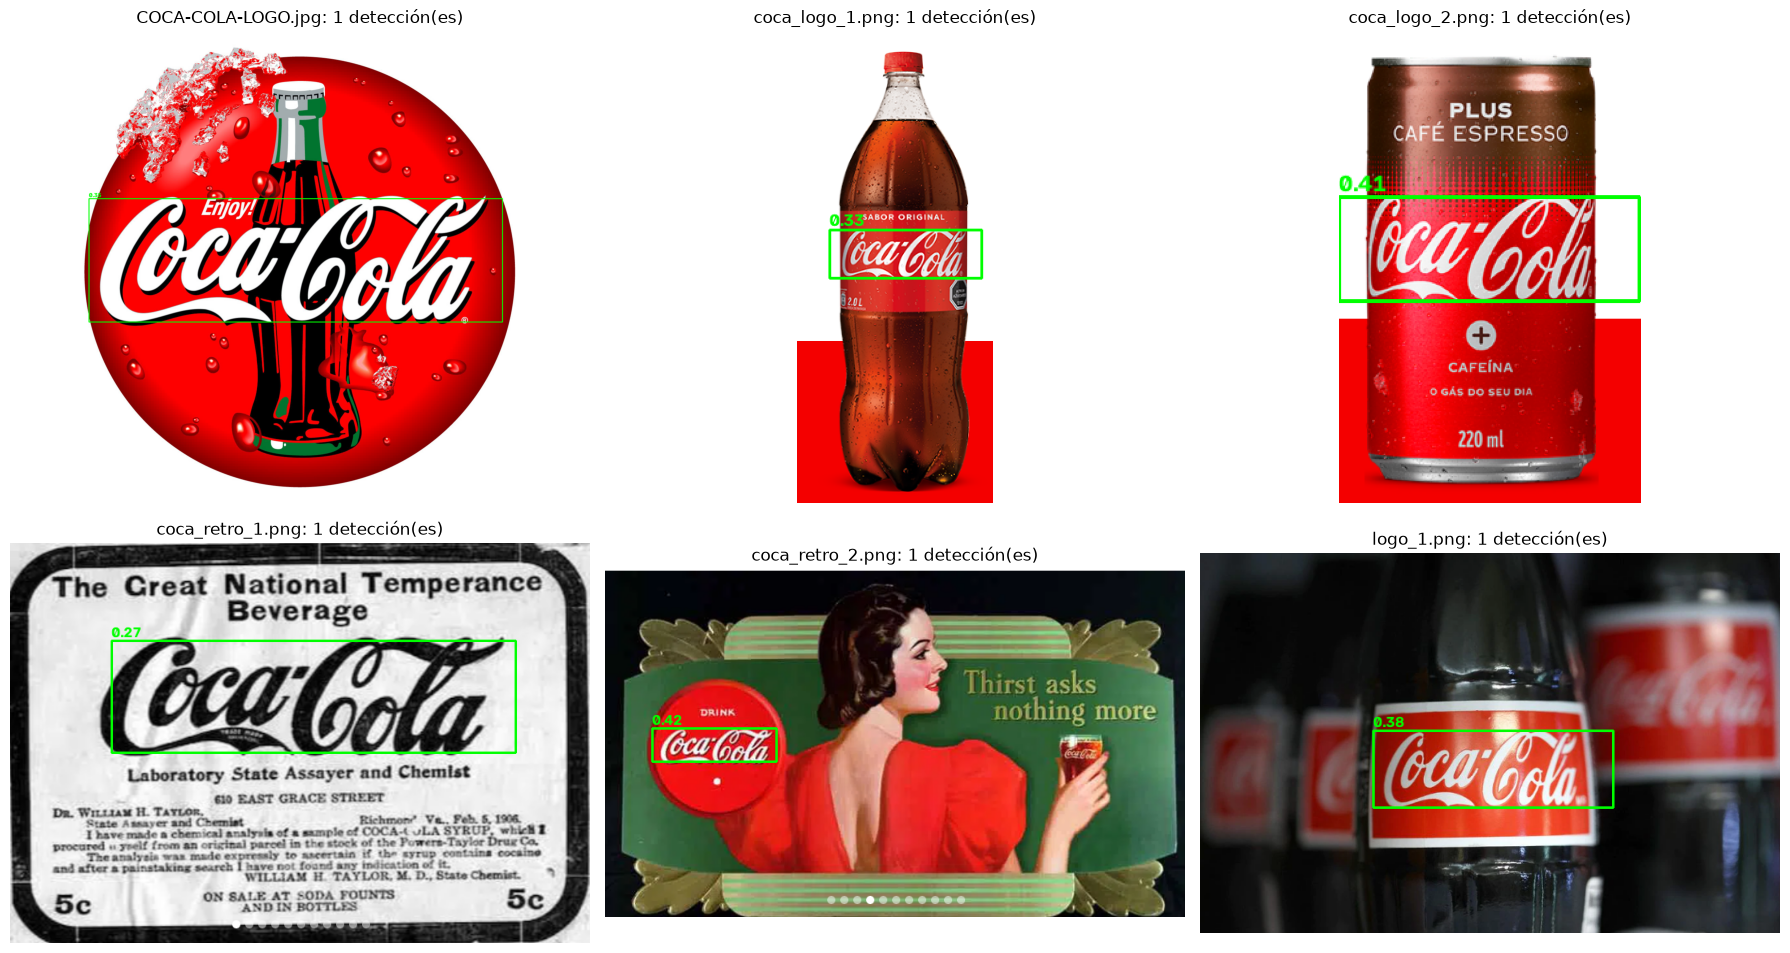

In [3]:
mostrar([p for p in paths if 'multi' not in p], detectar_uno)

### 2. Plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1

Extendemos el enfoque del ítem 1 (SIFT + matching + homografía) para detectar tantos logos como haya:
- El matching va de la imagen al template: así el test de Lowe no falla cuando el logo está repetido en la imagen (con varios logos, el segundo mejor match de un punto del template sería otra copia del mismo punto).
- Cada match vota por el centro y la escala del logo, usando la posición del keypoint en el template y la relación de tamaños entre keypoints.
- Tomamos el grupo más votado, calculamos la homografía con RANSAC sólo con esos matches, los descartamos y repetimos hasta que no queden grupos con suficientes matches.
- Al final aplicamos supresión de no-máximos (por si el template y su negativo detectan el mismo logo) y recortamos las cajas a la imagen.

19 logos detectados


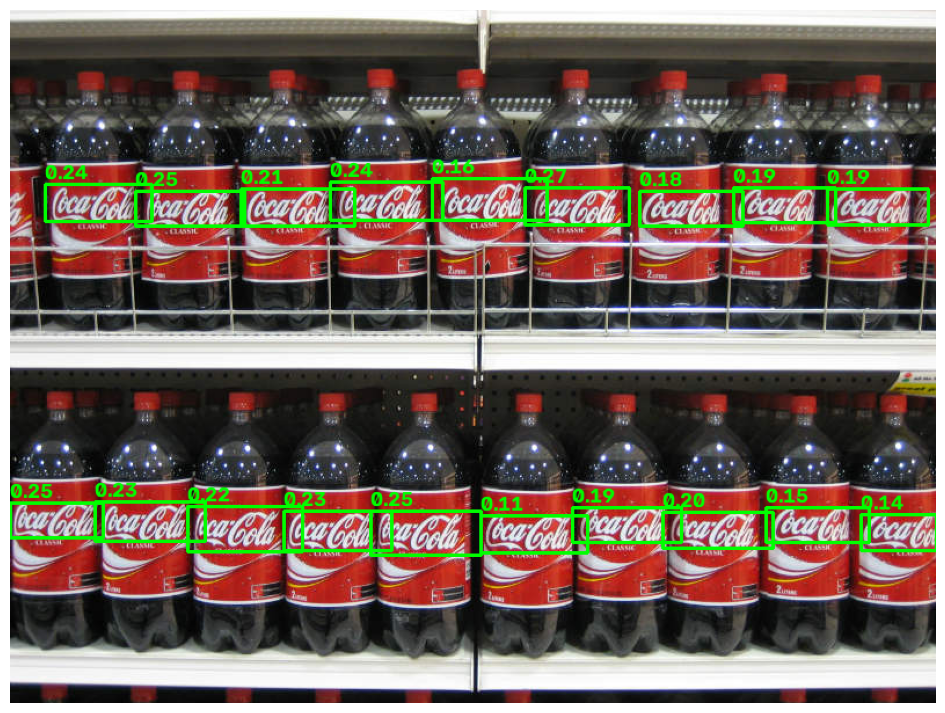

In [4]:
RADIO_VOTO = 0.35   # dos votos son del mismo logo si sus centros distan menos de esta fracción del ancho del logo
TOL_ESCALA = 0.5    # diferencia máxima de log-escala entre votos del mismo logo (factor ~1.65)


def detectar_multi(img):
    """Devuelve una lista de (x0, y0, x1, y1, confianza, inliers), una por logo."""
    cv.setRNGSeed(0)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray, None)
    dets = []
    for kp1, des1 in plantillas:
        # matching imagen -> template con test de Lowe
        matches = [m for m in flann.knnMatch(des2, des1, k=2) if len(m) == 2]
        good = [a for a, b in matches if a.distance < RATIO * b.distance]

        # cada match vota por el centro y la escala del logo
        escalas = np.array([kp2[m.queryIdx].size / kp1[m.trainIdx].size for m in good])
        votos = np.array([kp2[m.queryIdx].pt - s * (np.array(kp1[m.trainIdx].pt) - [w / 2, h / 2])
                          for m, s in zip(good, escalas)])

        vivo = np.ones(len(good), bool)
        while vivo.sum() >= MIN_INLIERS:
            idx = np.where(vivo)[0]
            dist = np.linalg.norm(votos[idx][:, None] - votos[idx][None], axis=2)
            dif_escala = np.abs(np.log(escalas[idx][:, None] / escalas[idx][None]))
            cerca = (dist < RADIO_VOTO * w * escalas[idx][:, None]) & (dif_escala < TOL_ESCALA)
            j = cerca.sum(axis=1).argmax()
            if cerca[j].sum() < MIN_INLIERS:
                break
            grupo = idx[cerca[j]]
            vivo[grupo] = False
            src_pts = np.float32([kp1[good[i].trainIdx].pt for i in grupo]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[good[i].queryIdx].pt for i in grupo]).reshape(-1, 1, 2)
            M, mask = homografia(src_pts, dst_pts, np.median(escalas[grupo]) * w)
            if M is not None and mask.sum() >= MIN_INLIERS:
                q = cv.perspectiveTransform(pts, M).reshape(-1, 2)
                dets.append((*q.min(axis=0), *q.max(axis=0), confianza(gray, M), int(mask.sum())))
    return [recortar(d, img.shape) for d in suprimir_duplicados(dets)]


multi = cargar(RAIZ + 'images/coca_multi.png')
dets = detectar_multi(multi)
print(f'{len(dets)} logos detectados')

plt.figure(figsize=(12, 9))
plt.imshow(cv.cvtColor(dibujar(multi, dets), cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#### Alternativa evaluada: template matching multiescala sobre bordes

También probamos template matching (`TM_CCOEFF_NORMED`) sobre mapas de bordes de Canny, con el umbral de Canny tomado de Otsu. Probamos varias escalas del logo (entre el 6% del ancho de la imagen y el máximo que entra), aceptamos los puntos con score >= 70% del máximo y suprimimos los no-máximos con IoU.

En `coca_multi.png` funciona bien, pero el umbral es relativo al mejor score de cada imagen: cuando hay un solo logo, ese criterio acepta también regiones que no son el logo. Por eso no generaliza al resto de las imágenes (ver los conteos abajo) y elegimos el enfoque con SIFT para los ítems 2 y 3.

In [5]:
REL = 0.7         # score mínimo, relativo al máximo
ANCHO_REF = 100   # ancho (px) al que llevamos el logo en cada escala


def iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    return inter / ((a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter)


def detectar_tm(img):
    """Devuelve una lista de (x0, y0, x1, y1, score)."""
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    H, W = gray.shape
    # el logo de referencia mide ANCHO_REF px; se reescala la imagen
    alto_ref = round(ANCHO_REF * h / w)
    t_ref = bordes(cv.resize(template, (ANCHO_REF, alto_ref))).astype(np.float32)
    mapas = []
    for ancho in np.linspace(max(40, 0.06 * W), min(W, H * w / h), 40):
        f = ANCHO_REF / ancho
        g = cv.resize(gray, None, fx=f, fy=f)
        if g.shape[0] > alto_ref and g.shape[1] > ANCHO_REF:
            mapas.append((ancho, f, cv.matchTemplate(bordes(g).astype(np.float32), t_ref, cv.TM_CCOEFF_NORMED)))

    threshold = REL * max(res.max() for _, _, res in mapas)
    dets = []
    for ancho, f, res in mapas:
        ys, xs = np.where(res >= threshold)
        dets += [(x / f, y / f, x / f + ancho, y / f + ancho * h / w, float(res[y, x])) for x, y in zip(xs, ys)]

    # supresión de no-máximos: el de mayor score gana
    final = []
    for d in sorted(dets, key=lambda d: -d[4]):
        if all(iou(d, k) < 0.3 for k in final):
            final.append(d)
    return final


print(f'coca_multi.png: {len(detectar_tm(multi))} logos detectados con template matching')
print('El mismo algoritmo en las imágenes con un solo logo:')
for p in paths:
    if 'multi' not in p:
        print(f'  {os.path.basename(p)}: {len(detectar_tm(cargar(p)))} detección(es)')

coca_multi.png: 17 logos detectados con template matching
El mismo algoritmo en las imágenes con un solo logo:
  COCA-COLA-LOGO.jpg: 1 detección(es)
  coca_logo_1.png: 1 detección(es)
  coca_logo_2.png: 28 detección(es)


  coca_retro_1.png: 1 detección(es)
  coca_retro_2.png: 1 detección(es)
  logo_1.png: 3 detección(es)


### 3. Generalizar el algoritmo del ítem 2 para todas las imágenes

Aplicamos el mismo detector del ítem 2 (`detectar_multi`), sin cambios, a todas las imágenes. No hace falta adaptarlo: como cada logo se encuentra como un grupo de votos independiente, el algoritmo devuelve una detección por cada logo que haya, sea uno o muchos, y todos los parámetros son relativos al tamaño del logo en la imagen, así que no dependen de la resolución.

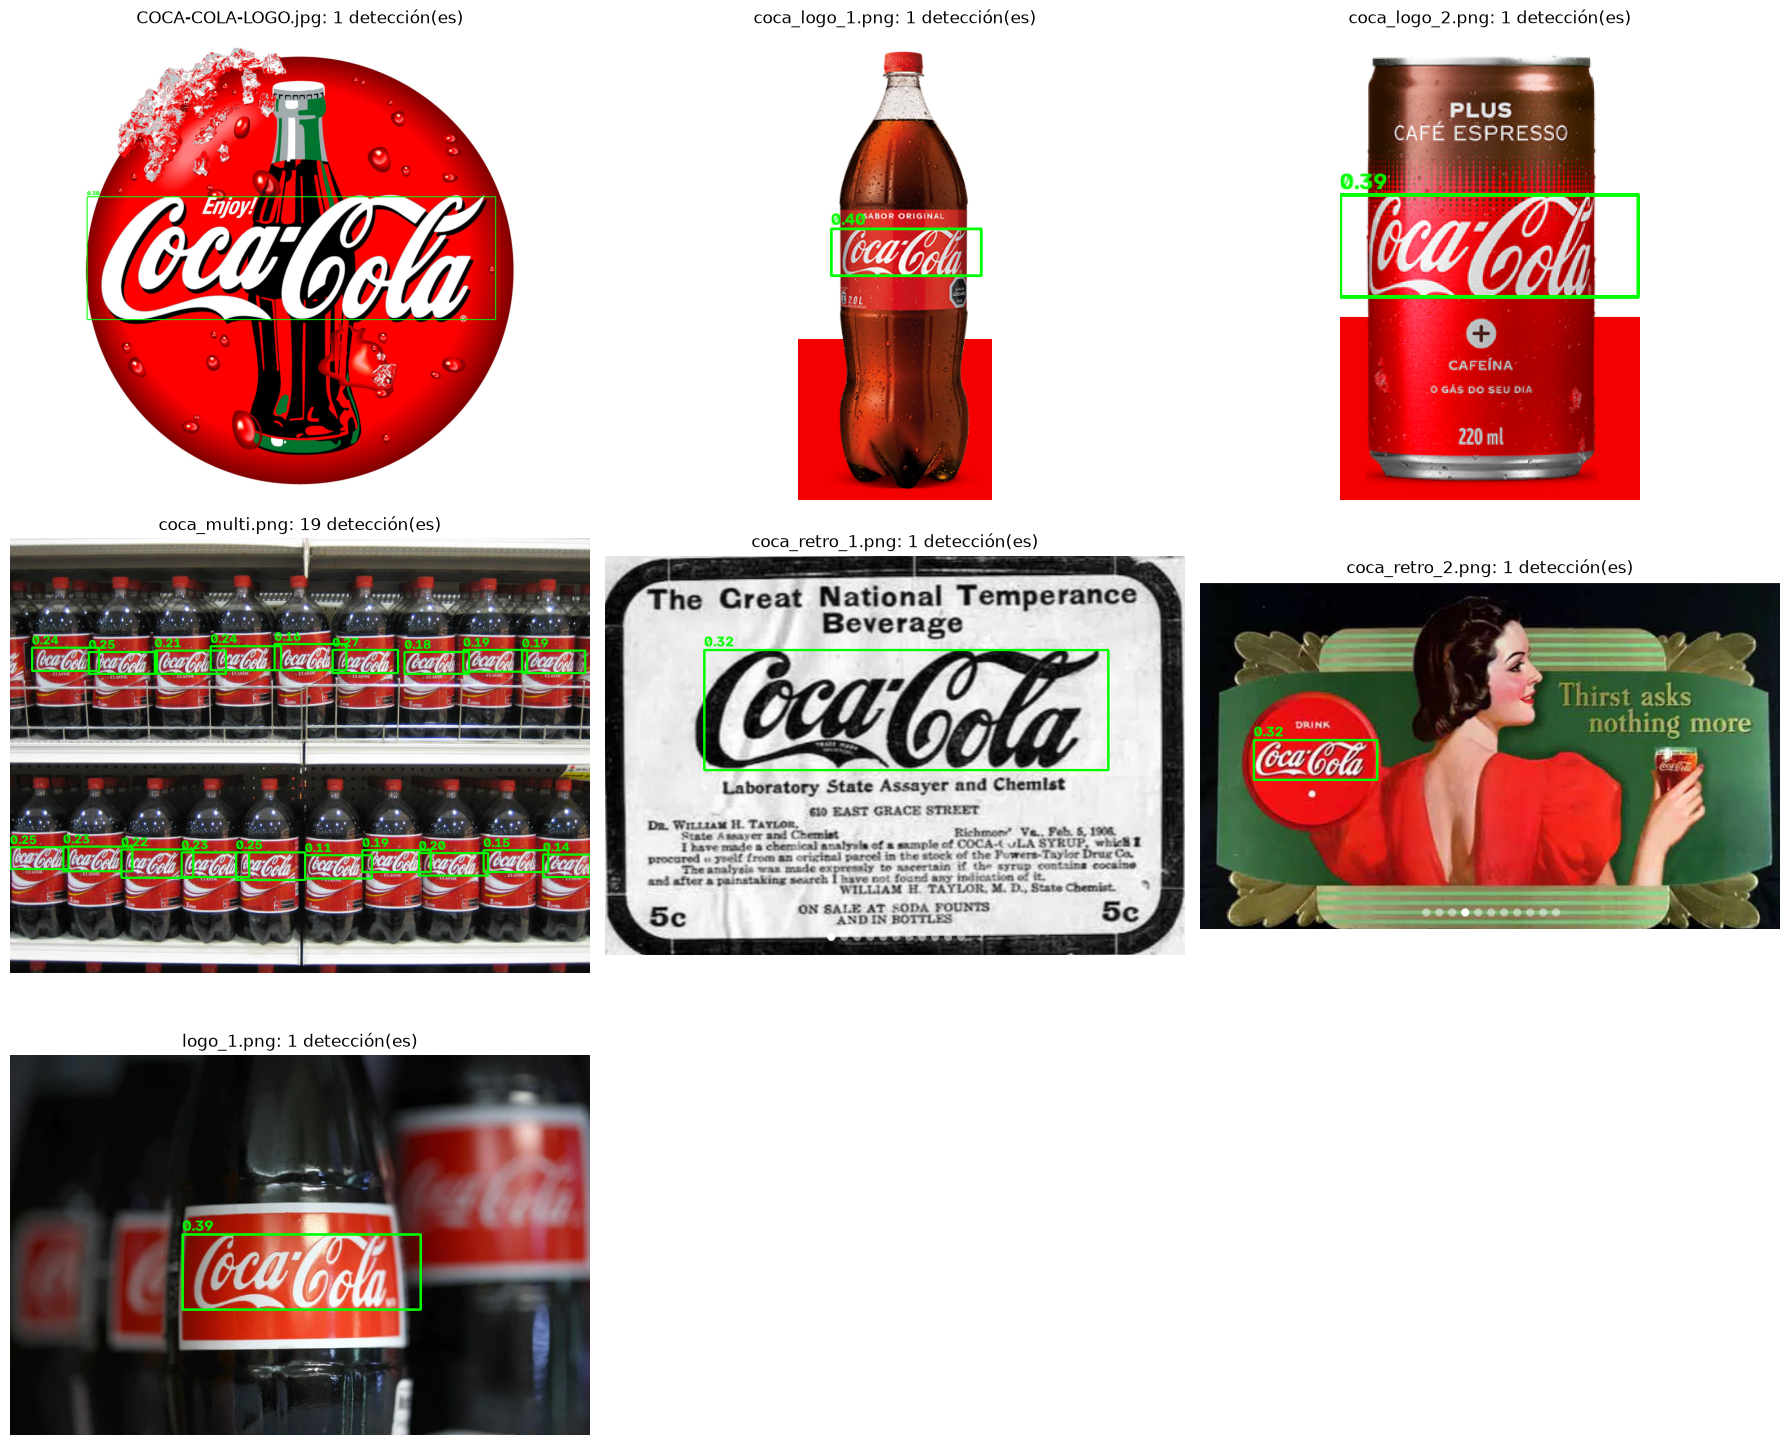

In [6]:
mostrar(paths, detectar_multi)

### Parámetros

Ningún parámetro está ajustado a una imagen o resolución en particular: los umbrales que dependen del tamaño se expresan como fracción del logo en la imagen, y los de Canny y el recorte del template salen de Otsu.

| Parámetro | Valor | Justificación |
|---|---|---|
| Recorte del template | Otsu | Separa el logo del fondo blanco del template |
| Umbrales de Canny | Otsu (`0.5·t`, `t`) | Se adaptan al contraste de cada imagen |
| `RATIO` | 0.7 | Test de Lowe, valor propuesto en el paper de SIFT |
| `MIN_INLIERS` | 8 | El doble de las 4 correspondencias mínimas de una homografía |
| `TOL_RANSAC` | 3% del ancho del logo | Error de reproyección relativo a la escala de la detección |
| `RADIO_VOTO` | 35% del ancho del logo | Agrupa votos del mismo logo; logos vecinos quedan a más de un ancho |
| `TOL_ESCALA` | 0.5 (log) | Votos de un mismo logo con escalas dentro de un factor ~1.65 |
| Supresión de no-máximos | centro contenido en otra caja | No requiere umbral de IoU |